In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from tqdm.notebook import tqdm
import re
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from collections import Counter
import pandas as pd
import numpy as np
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Loading the Data

In [ ]:
def load_data(path):
    pairs = []

    with open(path, encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) != 2:
                continue
            src, trg = parts
            pairs.append((src, trg))

    random.shuffle(pairs)

    return pairs


file_path = "/content/drive/MyDrive/Deep Learning/Exp6/spa.txt"
base_path = "/content/drive/MyDrive/Deep Learning/Exp6"
os.makedirs(base_path, exist_ok=True)

pairs = load_data(file_path)

print("Total sentences:", len(pairs))

Total sentences: 118121


In [ ]:
train_size = int(0.8 * len(pairs))
val_size = int(0.1 * len(pairs))

train_pairs = pairs[:train_size]
val_pairs = pairs[train_size:train_size+val_size]
test_pairs = pairs[train_size+val_size:]

print("Training Data:", len(train_pairs))
print("Validation Data:", len(val_pairs))
print("Testing Data:", len(test_pairs))

Training Data: 94496
Validation Data: 11812
Testing Data: 11813


### Preprocessing and Vocabulary Generation

In [ ]:
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
smooth = SmoothingFunction().method1

def tokenize(text):
    text = text.lower().strip()
    text = re.sub(r"[^\w\s]", "", text)
    return text.split()

class Vocabulary:
    def __init__(self):
        self.word2idx = {PAD_TOKEN:0, SOS_TOKEN:1, EOS_TOKEN:2, UNK_TOKEN:3}
        self.idx2word = {v: k for k, v in self.word2idx.items()}
        self.count = len(self.word2idx)

    def build(self, sentences):
        counter = Counter()
        for s in sentences:
            counter.update(tokenize(s))
        for word in sorted(counter.keys()):
            if word not in self.word2idx:
                self.word2idx[word] = self.count
                self.idx2word[self.count] = word
                self.count += 1

    def numericalize(self, sentence):
        index = [self.word2idx.get(w,self.word2idx[UNK_TOKEN]) for w in tokenize(sentence)]
        index = ([self.word2idx[SOS_TOKEN]] + index + [self.word2idx[EOS_TOKEN]])
        return index

In [ ]:
src_vocab = Vocabulary()
trg_vocab = Vocabulary()

src_vocab.build([p[0] for p in train_pairs])
trg_vocab.build([p[1] for p in train_pairs])

print("Source Vocabulary Size:", src_vocab.count)
print("Target Vocabulary Size:", trg_vocab.count)

Source Vocabulary Size: 12604
Target Vocabulary Size: 23619


### DataLoader Creation

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, trg = self.pairs[idx]
        src_seq = src_vocab.numericalize(src)
        trg_seq = trg_vocab.numericalize(trg)
        return torch.tensor(src_seq), torch.tensor(trg_seq)

def collate_fn(batch):
    src_batch, trg_batch = zip(*batch)

    src_batch = pad_sequence(src_batch, batch_first=True, padding_value=0)
    trg_batch = pad_sequence(trg_batch, batch_first=True, padding_value=0)

    return src_batch, trg_batch

train_loader = DataLoader(CustomDataset(train_pairs), batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(CustomDataset(val_pairs), batch_size=64, collate_fn=collate_fn)
test_loader = DataLoader(CustomDataset(test_pairs), batch_size=1, collate_fn=collate_fn)

### Defining the Encoder-Decoder Architecture

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim=128, hidden_dim=256):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        embedded = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, hidden, cell

In [ ]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim=128, hidden_dim=256):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, hidden, cell):
        x = x.unsqueeze(1)
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        prediction = self.fc(output.squeeze(1))
        return prediction, hidden, cell

### Defining the Attention Blocks

In [ ]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim=256):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.V = nn.Linear(hidden_dim, 1)

    def forward(self, hidden, encoder_outputs):
        hidden = hidden[-1].unsqueeze(1)
        score = self.V(torch.tanh(self.W1(encoder_outputs) + self.W2(hidden)))
        attn = torch.softmax(score, dim=1)
        context = torch.sum(attn * encoder_outputs, dim=1)
        return context, attn

In [ ]:
class LuongAttention(nn.Module):
    def forward(self, hidden, encoder_outputs):
        hidden = hidden[-1].unsqueeze(2)
        score = torch.bmm(encoder_outputs, hidden).squeeze(2)
        attn = torch.softmax(score, dim=1)
        context = torch.bmm(attn.unsqueeze(1), encoder_outputs).squeeze(1)
        return context, attn

In [ ]:
class DecoderAttention(nn.Module):
    def __init__(self, output_dim, attention, emb_dim=128, hidden_dim=256):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.attention = attention
        self.lstm = nn.LSTM(emb_dim+hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, hidden, cell, encoder_outputs):
        x = x.unsqueeze(1)
        embedded = self.embedding(x)
        context, attn = self.attention(hidden, encoder_outputs)
        lstm_input = torch.cat((embedded, context.unsqueeze(1)), dim=2)
        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        prediction = self.fc(output.squeeze(1))
        return prediction, hidden, cell, attn

### Training Loop

In [ ]:
def train_model(model, trg_vocab, epochs=50, save_path="model.pt"):
    optimizer = optim.Adam(model.parameters())
    criterion = nn.CrossEntropyLoss(ignore_index=0)

    train_losses, val_losses = [], []
    train_bleus, val_bleus = [], []

    for epoch in range(epochs):
        start_time = time.time()
        model.train()

        total_loss = 0
        hypotheses, references = [], []

        pbar = tqdm(train_loader)

        for src, trg in pbar:
            src, trg = src.to(device), trg.to(device)
            optimizer.zero_grad()

            enc_out, hidden, cell = model.encoder(src)
            input_token = trg[:,0]
            loss = 0

            batch_preds = []

            for t in range(1, trg.shape[1]):
                if hasattr(model.decoder, "attention"):
                    output, hidden, cell, _ = model.decoder(
                        input_token, hidden, cell, enc_out)
                else:
                    output, hidden, cell = model.decoder(
                        input_token, hidden, cell)

                loss += criterion(output, trg[:,t])
                preds = output.argmax(1)
                batch_preds.append(preds.unsqueeze(1))
                input_token = trg[:,t]

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

            batch_preds = torch.cat(batch_preds, dim=1).cpu().numpy()
            trg_seq = trg[:,1:].cpu().numpy()

            for pred_sent, ref_sent in zip(batch_preds, trg_seq):
                pred_words = [trg_vocab.idx2word[idx] for idx in pred_sent if idx not in [0,2]]
                ref_words = [[trg_vocab.idx2word[idx] for idx in ref_sent if idx not in [0,2]]]
                hypotheses.append(pred_words)
                references.append(ref_words)

            pbar.set_postfix(train_loss=loss.item())

        train_bleu = corpus_bleu(references, hypotheses,smoothing_function=smooth)
        train_losses.append(total_loss/len(train_loader))
        train_bleus.append(train_bleu)

        val_loss, val_bleu = evaluate(model, criterion, trg_vocab)
        val_losses.append(val_loss)
        val_bleus.append(val_bleu)

        print(f"Epoch {epoch+1}: Train Loss: {train_losses[-1]:.4f} Train BLEU: {train_bleus[-1]:.4f} Val Loss: {val_losses[-1]:.4f} Val BLEU: {val_bleus[-1]:.4f}")

    torch.save(model.state_dict(), save_path)
    print("Saved:", save_path)

    return train_bleus, val_bleus, train_losses, val_losses

### Validation Evaluation

In [ ]:
def evaluate(model, criterion, trg_vocab):
    model.eval()
    total_loss = 0
    references, hypotheses = [], []

    with torch.no_grad():
        for src, trg in val_loader:
            src, trg = src.to(device), trg.to(device)
            enc_out, hidden, cell = model.encoder(src)
            input_token = trg[:,0]
            loss = 0
            batch_preds = []

            for t in range(1, trg.shape[1]):
                if hasattr(model.decoder, "attention"):
                    output, hidden, cell, _ = model.decoder(
                        input_token, hidden, cell, enc_out)
                else:
                    output, hidden, cell = model.decoder(
                        input_token, hidden, cell)

                loss += criterion(output, trg[:,t])
                preds = output.argmax(1)
                batch_preds.append(preds.unsqueeze(1))
                input_token = trg[:,t]

            total_loss += loss.item()

            batch_preds = torch.cat(batch_preds, dim=1).cpu().numpy()
            trg_seq = trg[:,1:].cpu().numpy()

            for pred_sent, ref_sent in zip(batch_preds, trg_seq):
                pred_words = [trg_vocab.idx2word[idx] for idx in pred_sent if idx not in [0,2]]
                ref_words = [[trg_vocab.idx2word[idx] for idx in ref_sent if idx not in [0,2]]]
                hypotheses.append(pred_words)
                references.append(ref_words)

    bleu = corpus_bleu(references, hypotheses,smoothing_function=smooth)
    return total_loss/len(val_loader), bleu

In [ ]:
def plot(train_losses, val_losses, train_bleus, val_bleus):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(np.array(train_losses), label='Training Loss')
    axes[0].plot(np.array(val_losses), label='Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training vs Validation Loss')
    axes[0].legend()

    axes[1].plot(np.array(train_bleus), label='Training BLEU')
    axes[1].plot(np.array(val_bleus), label='Validation BLEU')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('BLEU Score')
    axes[1].set_title('Training vs Validation BLEU')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### Testing BLEU Computation

In [ ]:
def compute_bleu(model):
    model.eval()
    references, hypotheses = [], []

    with torch.no_grad():
        for src, trg in test_loader:
            src = src.to(device)
            enc_out, hidden, cell = model.encoder(src)

            max_len = trg.size(1)

            input_token = torch.tensor([1]).to(device)
            result = []

            for _ in range(max_len):
                if hasattr(model.decoder,"attention"):
                    output, hidden, cell, _ = model.decoder(input_token, hidden, cell, enc_out)
                else:
                    output, hidden, cell = model.decoder(input_token, hidden, cell)

                top = output.argmax(1)
                if top.item() == 2:
                    break
                result.append(trg_vocab.idx2word[top.item()])
                input_token = top

            hyp_tokens = result
            ref_tokens = [trg_vocab.idx2word[i.item()] for i in trg[0] if i.item() not in [0,1,2]]

            hypotheses.append(hyp_tokens)
            references.append([ref_tokens])

    bleu = corpus_bleu(references, hypotheses,smoothing_function=smooth)
    return bleu

### Attention Visualization

In [ ]:
def visualize_attention(model, n_sentences=4):
    model.eval()

    sentences = [pair[0] for pair in train_pairs[:n_sentences]]
    ncols = 2
    nrows = int(len(sentences)/ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
    axes = axes.flatten()

    for idx, sentence in enumerate(sentences):
        tokens = tokenize(sentence)

        src_seq = torch.tensor(
            src_vocab.numericalize(sentence)
        ).unsqueeze(0).to(device)

        enc_out, hidden, cell = model.encoder(src_seq)
        input_token = torch.tensor([1]).to(device)

        attentions = []
        outputs = []

        for _ in range(20):
            output, hidden, cell, attn = model.decoder(
                input_token, hidden, cell, enc_out)

            top = output.argmax(1)

            if top.item() == 2:
                break

            outputs.append(trg_vocab.idx2word[top.item()])
            attentions.append(attn.squeeze().cpu().detach().numpy())
            input_token = top

        ax = axes[idx]

        sns.heatmap(
            attentions,
            xticklabels=["<sos>"] + tokens + ["<eos>"],
            yticklabels=outputs,
            ax=ax,
            cmap="Blues_r"
        )

        ax.set_title(f"Sentence: {sentence}")
        ax.set_xlabel("Input")
        ax.set_ylabel("Output")

    for i in range(len(sentences), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

### Model without Attention

In [ ]:
# No Attention
no_attention = nn.Module()
no_attention.encoder = Encoder(src_vocab.count).to(device)
no_attention.decoder = Decoder(trg_vocab.count).to(device)
non_bleu, non_val_bleu, non_loss, non_val_loss = train_model(no_attention,trg_vocab, save_path="no_attention.pt")

  0%|          | 0/1477 [00:00<?, ?it/s]

Epoch 1: Train Loss: 83.3915 Train BLEU: 0.0026 Val Loss: 75.3913 Val BLEU: 0.0045


  0%|          | 0/1477 [00:00<?, ?it/s]

Epoch 2: Train Loss: 68.1348 Train BLEU: 0.0102 Val Loss: 68.6851 Val BLEU: 0.0162


  0%|          | 0/1477 [00:00<?, ?it/s]

...

Epoch 48: Train Loss: 2.7569 Train BLEU: 0.7656 Val Loss: 89.1252 Val BLEU: 0.1845


  0%|          | 0/1477 [00:00<?, ?it/s]

Epoch 49: Train Loss: 2.5842 Train BLEU: 0.7791 Val Loss: 90.1737 Val BLEU: 0.1840


  0%|          | 0/1477 [00:00<?, ?it/s]

Epoch 50: Train Loss: 2.2657 Train BLEU: 0.8004 Val Loss: 90.5449 Val BLEU: 0.1824
Saved: no_attention.pt


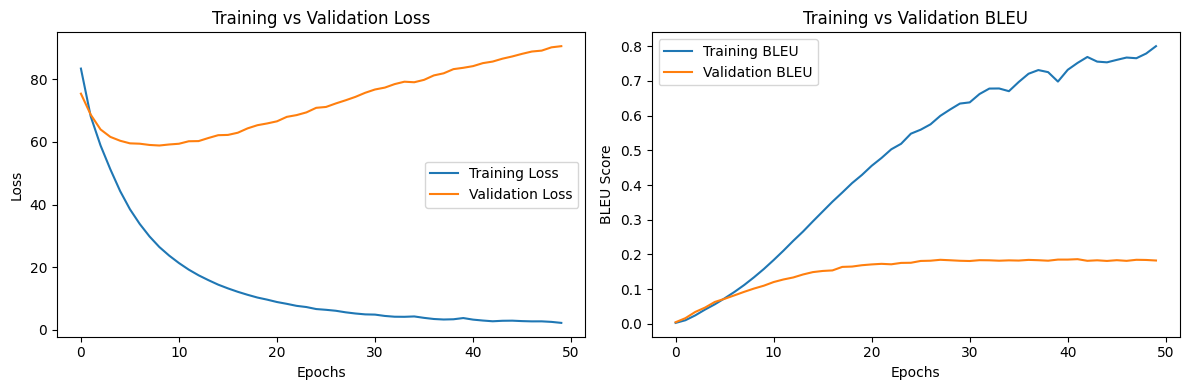

In [ ]:
plot(non_loss,non_val_loss,non_bleu,non_val_bleu)

In [ ]:
non_test_bleu = compute_bleu(no_attention)

### Bahdanau Attention Model

In [ ]:
# Bahdanau
bahdanau = nn.Module()
bahdanau.encoder = Encoder(src_vocab.count).to(device)
bahdanau.decoder = DecoderAttention(trg_vocab.count,BahdanauAttention()).to(device)
model_name = "bahdanau"
save_path = os.path.join(base_path, f"{model_name}.pt")
bahdanau_bleu, bahdanau_val_bleu, bahdanau_loss, bahdanau_val_loss = train_model(bahdanau,trg_vocab, save_path=save_path)

  0%|          | 0/1477 [00:00<?, ?it/s]

Epoch 1: Train Loss: 83.4987 Train BLEU: 0.0029 Val Loss: 75.0865 Val BLEU: 0.0073


  0%|          | 0/1477 [00:00<?, ?it/s]

Epoch 2: Train Loss: 66.7483 Train BLEU: 0.0154 Val Loss: 65.3107 Val BLEU: 0.0291


  0%|          | 0/1477 [00:00<?, ?it/s]

...

Epoch 48: Train Loss: 1.6593 Train BLEU: 0.8120 Val Loss: 65.4451 Val BLEU: 0.2936


  0%|          | 0/1477 [00:00<?, ?it/s]

Epoch 49: Train Loss: 2.0474 Train BLEU: 0.7779 Val Loss: 65.9651 Val BLEU: 0.2862


  0%|          | 0/1477 [00:00<?, ?it/s]

Epoch 50: Train Loss: 1.7823 Train BLEU: 0.7997 Val Loss: 65.2394 Val BLEU: 0.2922
Saved: /content/drive/MyDrive/Deep Learning/Exp6/bahdanau.pt


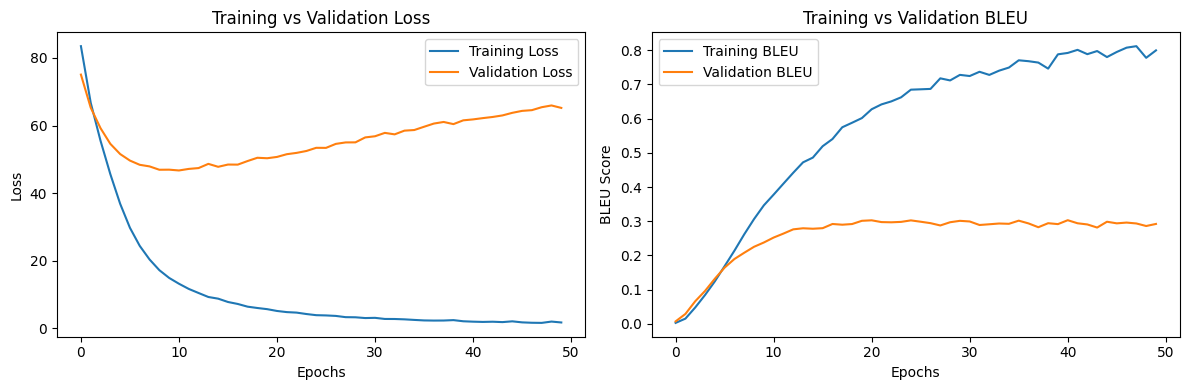

In [ ]:
plot(bahdanau_loss,bahdanau_val_loss,bahdanau_bleu,bahdanau_val_bleu)

In [ ]:
bahdanau_test_bleu = compute_bleu(bahdanau)

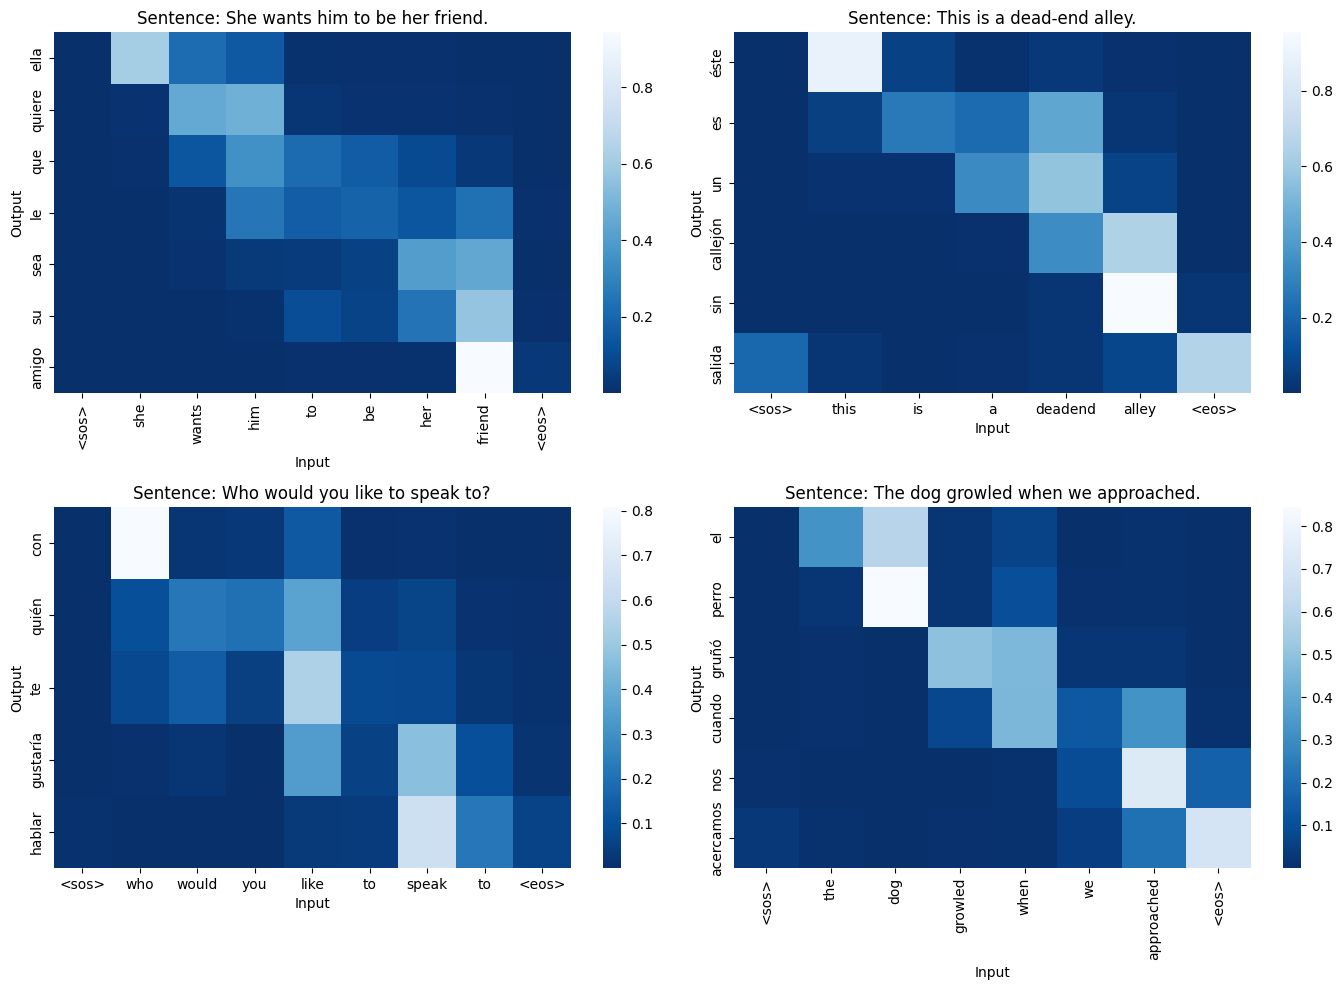

In [ ]:
visualize_attention(bahdanau)

### Luong Attention Model

In [ ]:
# Luong
luong = nn.Module()
luong.encoder = Encoder(src_vocab.count).to(device)
luong.decoder = DecoderAttention(trg_vocab.count,LuongAttention()).to(device)
model_name = "luong"
save_path = os.path.join(base_path, f"{model_name}.pt")
luong_bleu, luong_val_bleu, luong_loss, luong_val_loss = train_model(luong,trg_vocab, save_path=save_path)

  0%|          | 0/1477 [00:00<?, ?it/s]

Epoch 1: Train Loss: 83.9210 Train BLEU: 0.0022 Val Loss: 75.4896 Val BLEU: 0.0057


  0%|          | 0/1477 [00:00<?, ?it/s]

Epoch 2: Train Loss: 68.5575 Train BLEU: 0.0103 Val Loss: 67.3799 Val BLEU: 0.0168


  0%|          | 0/1477 [00:00<?, ?it/s]

...

Epoch 48: Train Loss: 2.8039 Train BLEU: 0.7677 Val Loss: 68.8494 Val BLEU: 0.2640


  0%|          | 0/1477 [00:00<?, ?it/s]

Epoch 49: Train Loss: 2.7932 Train BLEU: 0.7697 Val Loss: 68.8261 Val BLEU: 0.2641


  0%|          | 0/1477 [00:00<?, ?it/s]

Epoch 50: Train Loss: 2.7061 Train BLEU: 0.7749 Val Loss: 69.9438 Val BLEU: 0.2616
Saved: /content/drive/MyDrive/Deep Learning/Exp6/luong.pt


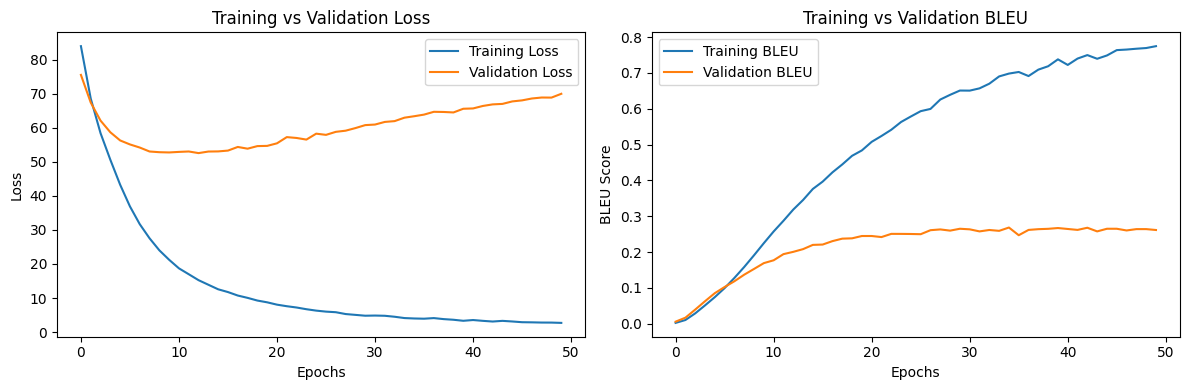

In [ ]:
plot(luong_loss,luong_val_loss,luong_bleu,luong_val_bleu)

In [ ]:
luong_test_bleu = compute_bleu(luong)

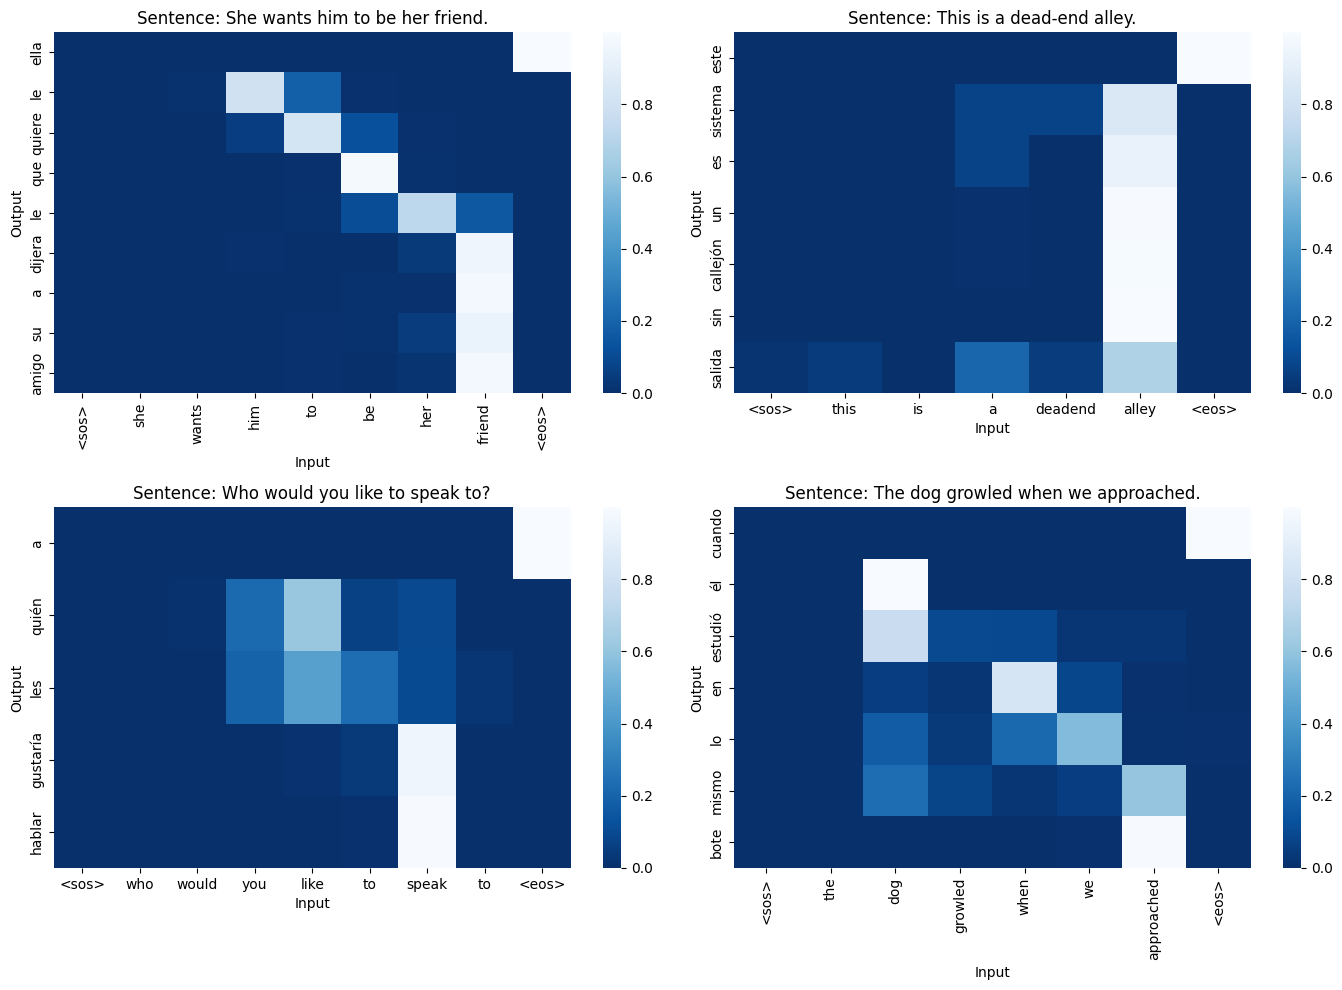

In [ ]:
visualize_attention(luong)

### Final Comparison

In [ ]:
results = pd.DataFrame({
    "Model":["No Attention","Bahdanau","Luong"],
    "Train BLEU":[non_bleu[-1],bahdanau_bleu[-1],luong_bleu[-1]],
    "Validation BLEU":[non_val_bleu[-1],bahdanau_val_bleu[-1],luong_val_bleu[-1]],
    "Test BLEU":[non_test_bleu,bahdanau_test_bleu,luong_test_bleu]
})
results

,Model,Train BLEU,Validation BLEU,Test BLEU
0,No Attention,0.800356,0.182427,0.121914
1,Bahdanau,0.799674,0.292227,0.253961
2,Luong,0.774874,0.261558,0.197405
